# Ритейл-аналитика: когортный анализ, retention и сегментация клиентов

**Цель проекта** — провести продуктовый анализ транзакций ритейлера: выявить паттерны удержания клиентов, оценить влияние сезонности, сегментировать аудиторию и сформулировать гипотезы для роста бизнеса.

**Методология:**
1. Разведочный анализ данных (EDA)
2. Когортный анализ по месяцу первой покупки
3. Retention-анализ (7, 30, 90 дней)
4. Тепловая карта удержания
5. Сегментация по способу оплаты и категории товаров
6. RFM-анализ
7. Анализ среднего чека и LTV
8. Выводы и гипотезы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

COLORS = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0', '#00BCD4']

## 1. Загрузка и первичный осмотр данных

In [2]:
df = pd.read_csv('Retail_Transaction_Dataset.csv')
print(f'Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов')
df.head()

Размер датасета: 100,000 строк × 10 столбцов


,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,8/5/2023 0:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,3/11/2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [3]:
df.info()
print('\n' + '=' * 60)
print(f'Уникальных клиентов: {df["CustomerID"].nunique():,}')
print(f'Уникальных продуктов: {df["ProductID"].nunique()}')
print(f'Категории товаров: {sorted(df["ProductCategory"].unique())}')
print(f'Способы оплаты: {sorted(df["PaymentMethod"].unique())}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  object 
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  object 
 5   PaymentMethod       100000 non-null  object 
 6   StoreLocation       100000 non-null  object 
 7   ProductCategory     100000 non-null  object 
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 7.6+ MB

Уникальных клиентов: 95,215
Уникальных продуктов: 4
Категории товаров: ['Books', 'Clothing', 'Electronics', 'Home Decor']
Способы оплаты: ['Cash', 'Credit Card', 'Debit Card', 'PayPal']


## 2. Подготовка данных

In [4]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['TransactionMonth'] = df['TransactionDate'].dt.to_period('M')
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()
df['Hour'] = df['TransactionDate'].dt.hour

df['State'] = df['StoreLocation'].str.extract(r',\s*([A-Z]{2})\s+\d{5}')

print(f'Период данных: {df["TransactionDate"].min().date()} — {df["TransactionDate"].max().date()}')
print(f'\nПропущенные значения:')
print(df.isnull().sum())
print(f'\nДубликаты: {df.duplicated().sum()}')

Период данных: 2023-04-29 — 2024-04-28

Пропущенные значения:
CustomerID                0
ProductID                 0
Quantity                  0
Price                     0
TransactionDate           0
PaymentMethod             0
StoreLocation             0
ProductCategory           0
DiscountApplied(%)        0
TotalAmount               0
TransactionMonth          0
DayOfWeek                 0
Hour                      0
State                 10806
dtype: int64



Дубликаты: 0


In [5]:
df.describe().round(2)

,CustomerID,Quantity,Price,TransactionDate,DiscountApplied(%),TotalAmount,Hour
count,100000.00,100000.00,100000.00,100000,100000.00,100000.00,100000.00
mean,500463.98,5.01,55.07,2023-10-29 15:40:05.471399936,10.02,248.33,11.48
min,14.00,1.00,10.00,2023-04-29 22:27:00,0.00,8.27,0.00
25%,250693.75,3.00,32.55,2023-07-30 06:45:15,5.00,95.16,5.00
50%,499679.00,5.00,55.12,2023-10-30 05:12:30,10.03,200.37,11.00
75%,751104.75,7.00,77.46,2024-01-29 05:44:00,15.02,362.01,17.00
max,999997.00,9.00,100.00,2024-04-28 22:22:00,20.00,896.14,23.00
std,288460.92,2.58,25.97,NaN,5.78,184.55,6.92


## 3. Разведочный анализ данных (EDA)

Изучим распределения ключевых метрик и паттерны в данных.

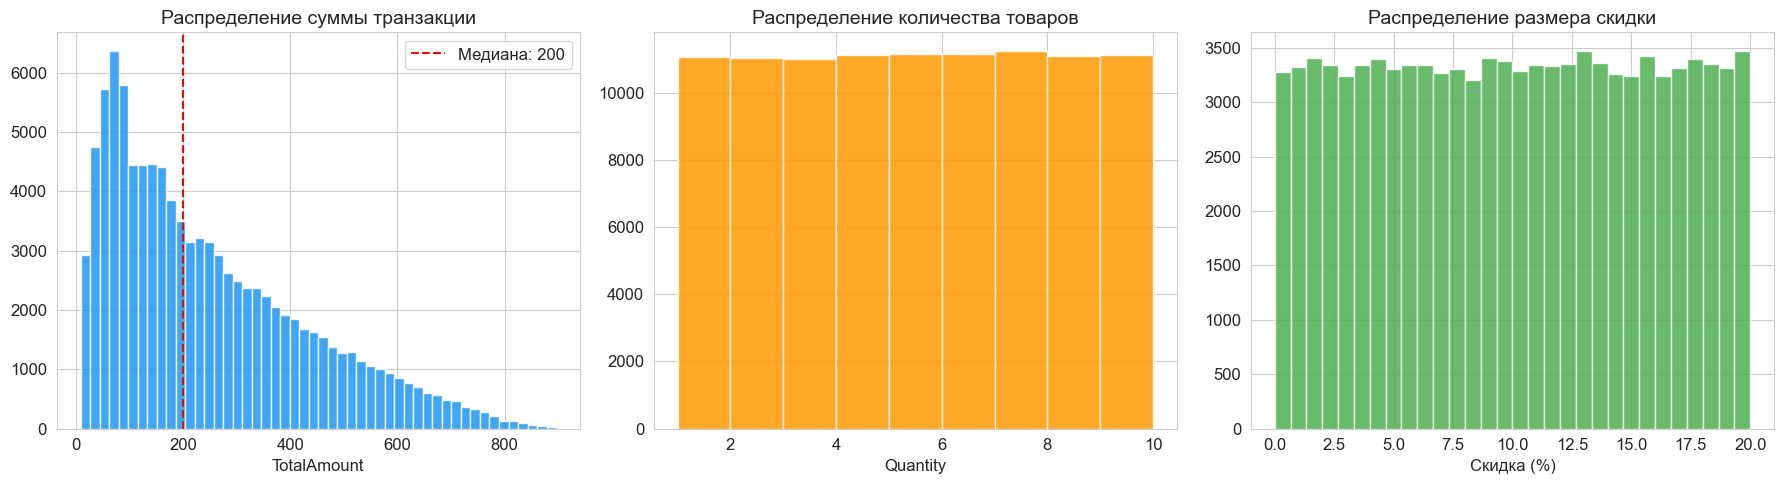

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['TotalAmount'], bins=50, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].set_title('Распределение суммы транзакции')
axes[0].set_xlabel('TotalAmount')
axes[0].axvline(df['TotalAmount'].median(), color='red', linestyle='--', label=f'Медиана: {df["TotalAmount"].median():.0f}')
axes[0].legend()

axes[1].hist(df['Quantity'], bins=range(1, df['Quantity'].max() + 2), color=COLORS[1], edgecolor='white', alpha=0.85)
axes[1].set_title('Распределение количества товаров')
axes[1].set_xlabel('Quantity')

axes[2].hist(df['DiscountApplied(%)'], bins=30, color=COLORS[2], edgecolor='white', alpha=0.85)
axes[2].set_title('Распределение размера скидки')
axes[2].set_xlabel('Скидка (%)')

plt.tight_layout()
plt.show()

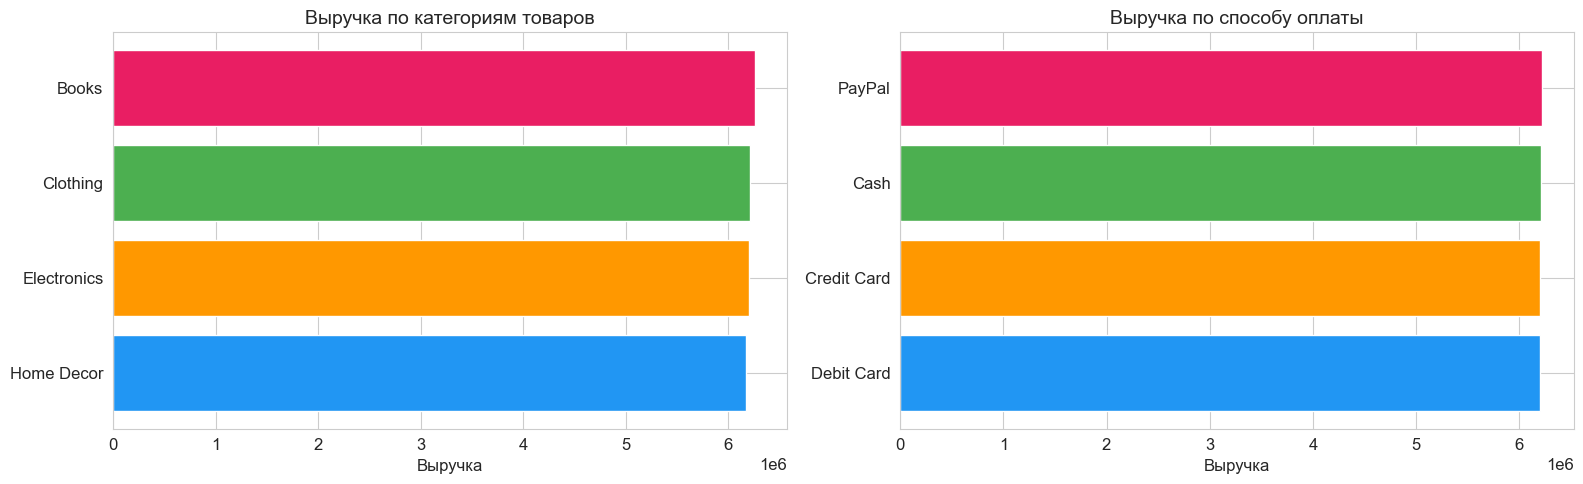

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_rev = df.groupby('ProductCategory')['TotalAmount'].agg(['sum', 'count']).sort_values('sum', ascending=True)
axes[0].barh(cat_rev.index, cat_rev['sum'], color=COLORS[:len(cat_rev)])
axes[0].set_title('Выручка по категориям товаров')
axes[0].set_xlabel('Выручка')

pay_rev = df.groupby('PaymentMethod')['TotalAmount'].agg(['sum', 'count']).sort_values('sum', ascending=True)
axes[1].barh(pay_rev.index, pay_rev['sum'], color=COLORS[:len(pay_rev)])
axes[1].set_title('Выручка по способу оплаты')
axes[1].set_xlabel('Выручка')

plt.tight_layout()
plt.show()

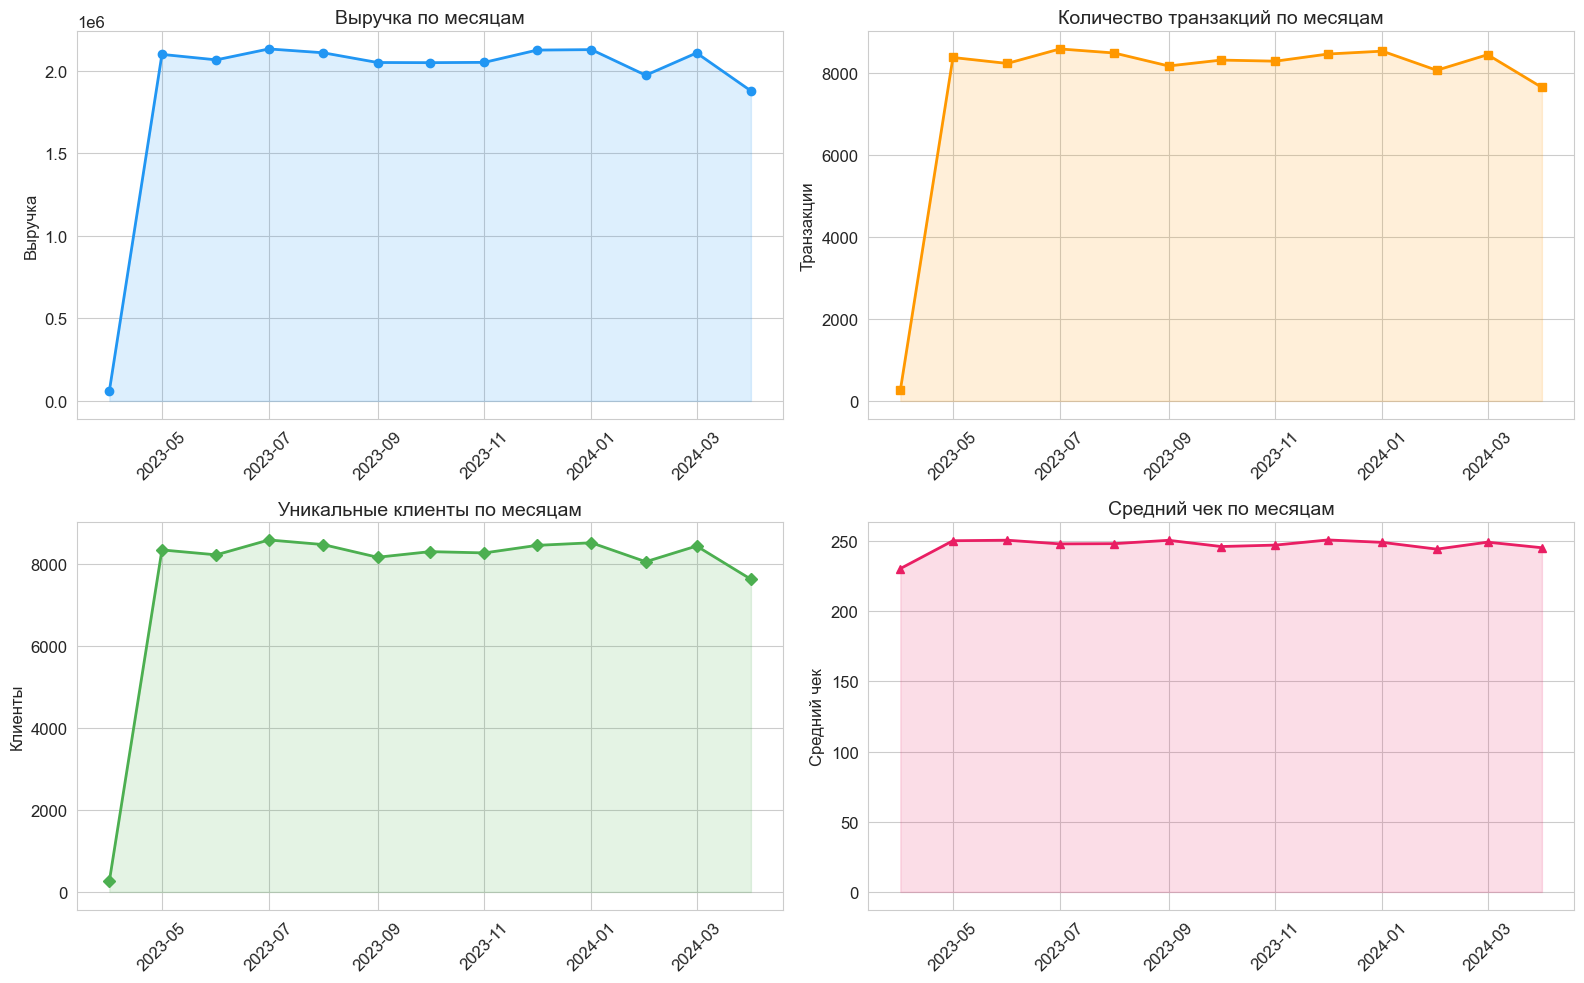

In [8]:
monthly = df.groupby('TransactionMonth').agg(
    revenue=('TotalAmount', 'sum'),
    transactions=('CustomerID', 'count'),
    customers=('CustomerID', 'nunique'),
    avg_check=('TotalAmount', 'mean')
).reset_index()
monthly['month_ts'] = monthly['TransactionMonth'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(monthly['month_ts'], monthly['revenue'], 'o-', color=COLORS[0], linewidth=2)
axes[0, 0].fill_between(monthly['month_ts'], monthly['revenue'], alpha=0.15, color=COLORS[0])
axes[0, 0].set_title('Выручка по месяцам')
axes[0, 0].set_ylabel('Выручка')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(monthly['month_ts'], monthly['transactions'], 's-', color=COLORS[1], linewidth=2)
axes[0, 1].fill_between(monthly['month_ts'], monthly['transactions'], alpha=0.15, color=COLORS[1])
axes[0, 1].set_title('Количество транзакций по месяцам')
axes[0, 1].set_ylabel('Транзакции')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(monthly['month_ts'], monthly['customers'], 'D-', color=COLORS[2], linewidth=2)
axes[1, 0].fill_between(monthly['month_ts'], monthly['customers'], alpha=0.15, color=COLORS[2])
axes[1, 0].set_title('Уникальные клиенты по месяцам')
axes[1, 0].set_ylabel('Клиенты')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].plot(monthly['month_ts'], monthly['avg_check'], '^-', color=COLORS[3], linewidth=2)
axes[1, 1].fill_between(monthly['month_ts'], monthly['avg_check'], alpha=0.15, color=COLORS[3])
axes[1, 1].set_title('Средний чек по месяцам')
axes[1, 1].set_ylabel('Средний чек')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

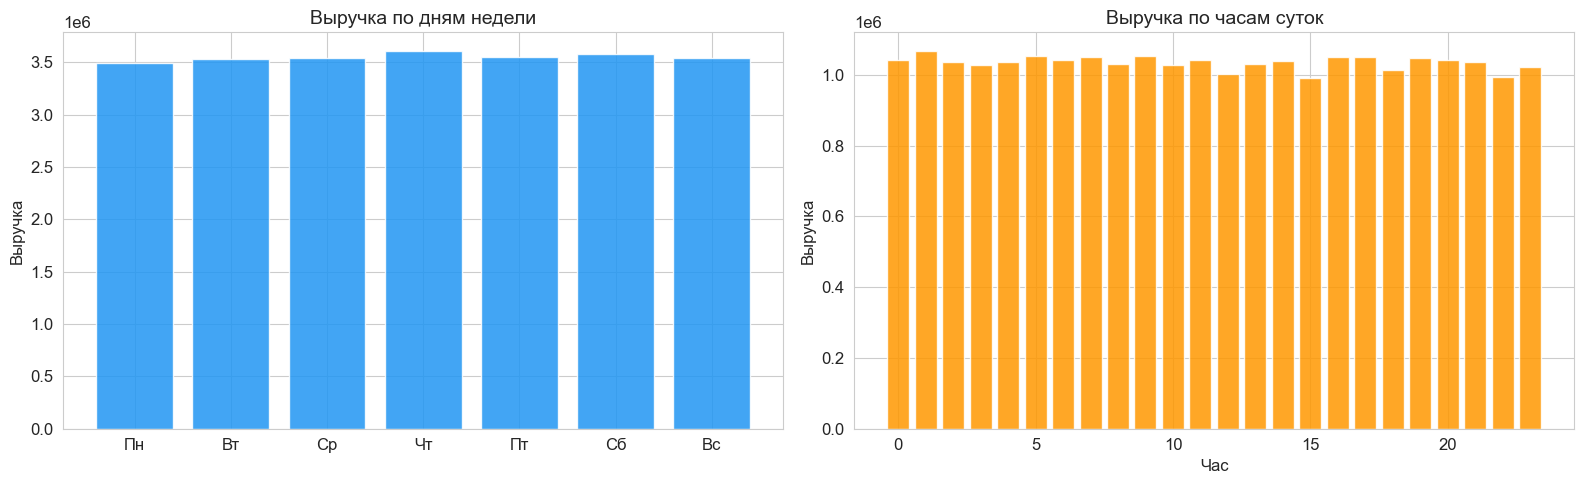

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
day_rev = df.groupby('DayOfWeek')['TotalAmount'].agg(['sum', 'count']).reindex(day_order)

axes[0].bar(range(7), day_rev['sum'], color=COLORS[0], alpha=0.85)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_labels)
axes[0].set_title('Выручка по дням недели')
axes[0].set_ylabel('Выручка')

hour_rev = df.groupby('Hour')['TotalAmount'].agg(['sum', 'count'])
axes[1].bar(hour_rev.index, hour_rev['sum'], color=COLORS[1], alpha=0.85)
axes[1].set_title('Выручка по часам суток')
axes[1].set_xlabel('Час')
axes[1].set_ylabel('Выручка')

plt.tight_layout()
plt.show()

## 4. Когортный анализ

Формируем когорты по месяцу первой покупки клиента. Это позволит отслеживать поведение каждой группы клиентов с момента их "приобретения".

In [10]:
first_purchase = df.groupby('CustomerID')['TransactionDate'].min().reset_index()
first_purchase.columns = ['CustomerID', 'FirstPurchaseDate']
first_purchase['Cohort'] = first_purchase['FirstPurchaseDate'].dt.to_period('M')

df = df.merge(first_purchase[['CustomerID', 'FirstPurchaseDate', 'Cohort']], on='CustomerID', how='left')
df['CohortPeriod'] = df['TransactionDate'].dt.to_period('M')
df['CohortIndex'] = (df['CohortPeriod'] - df['Cohort']).apply(lambda x: x.n)
df['DaysSinceFirst'] = (df['TransactionDate'] - df['FirstPurchaseDate']).dt.days

cohort_sizes = first_purchase.groupby('Cohort')['CustomerID'].nunique()
print('Размер когорт (количество новых клиентов):')
print(cohort_sizes.to_string())

Размер когорт (количество новых клиентов):
Cohort
2023-04     264
2023-05    8330
2023-06    8149
2023-07    8436
2023-08    8260
2023-09    7903
2023-10    7941
2023-11    7843
2023-12    7985
2024-01    7966
2024-02    7472
2024-03    7731
2024-04    6935
Freq: M


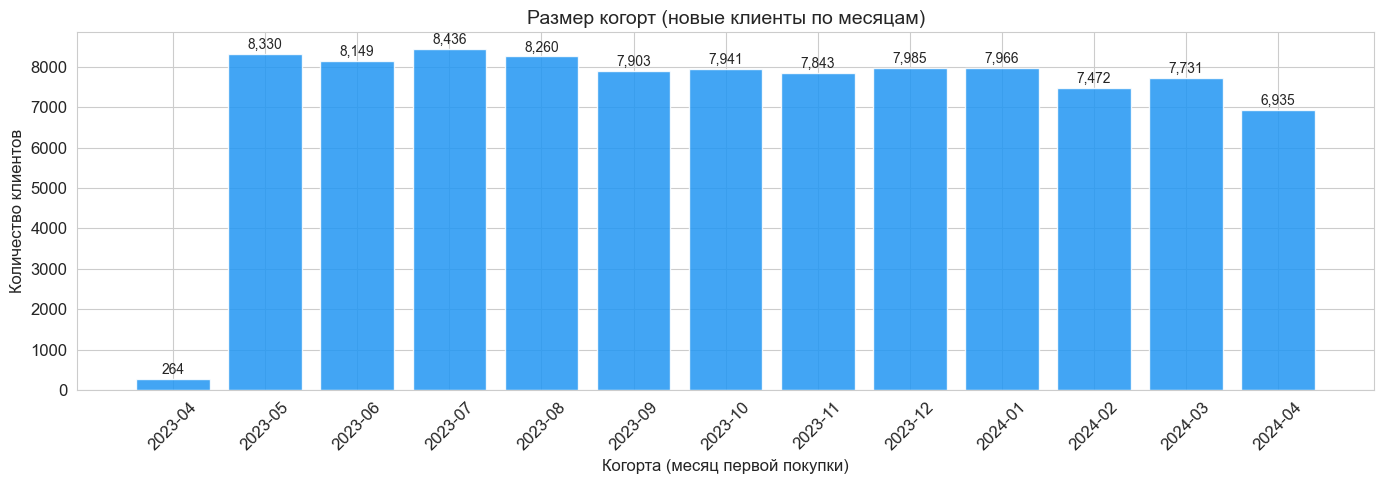

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
cs = cohort_sizes.reset_index()
cs['Cohort'] = cs['Cohort'].astype(str)
bars = ax.bar(cs['Cohort'], cs['CustomerID'], color=COLORS[0], alpha=0.85)

for bar, val in zip(bars, cs['CustomerID']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

ax.set_title('Размер когорт (новые клиенты по месяцам)', fontsize=14)
ax.set_xlabel('Когорта (месяц первой покупки)')
ax.set_ylabel('Количество клиентов')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Тепловая карта удержания

Retention rate — доля клиентов когорты, совершивших покупку в N-й месяц после первой покупки. Тепловая карта позволяет визуально выявить сезонные эффекты и аномалии.

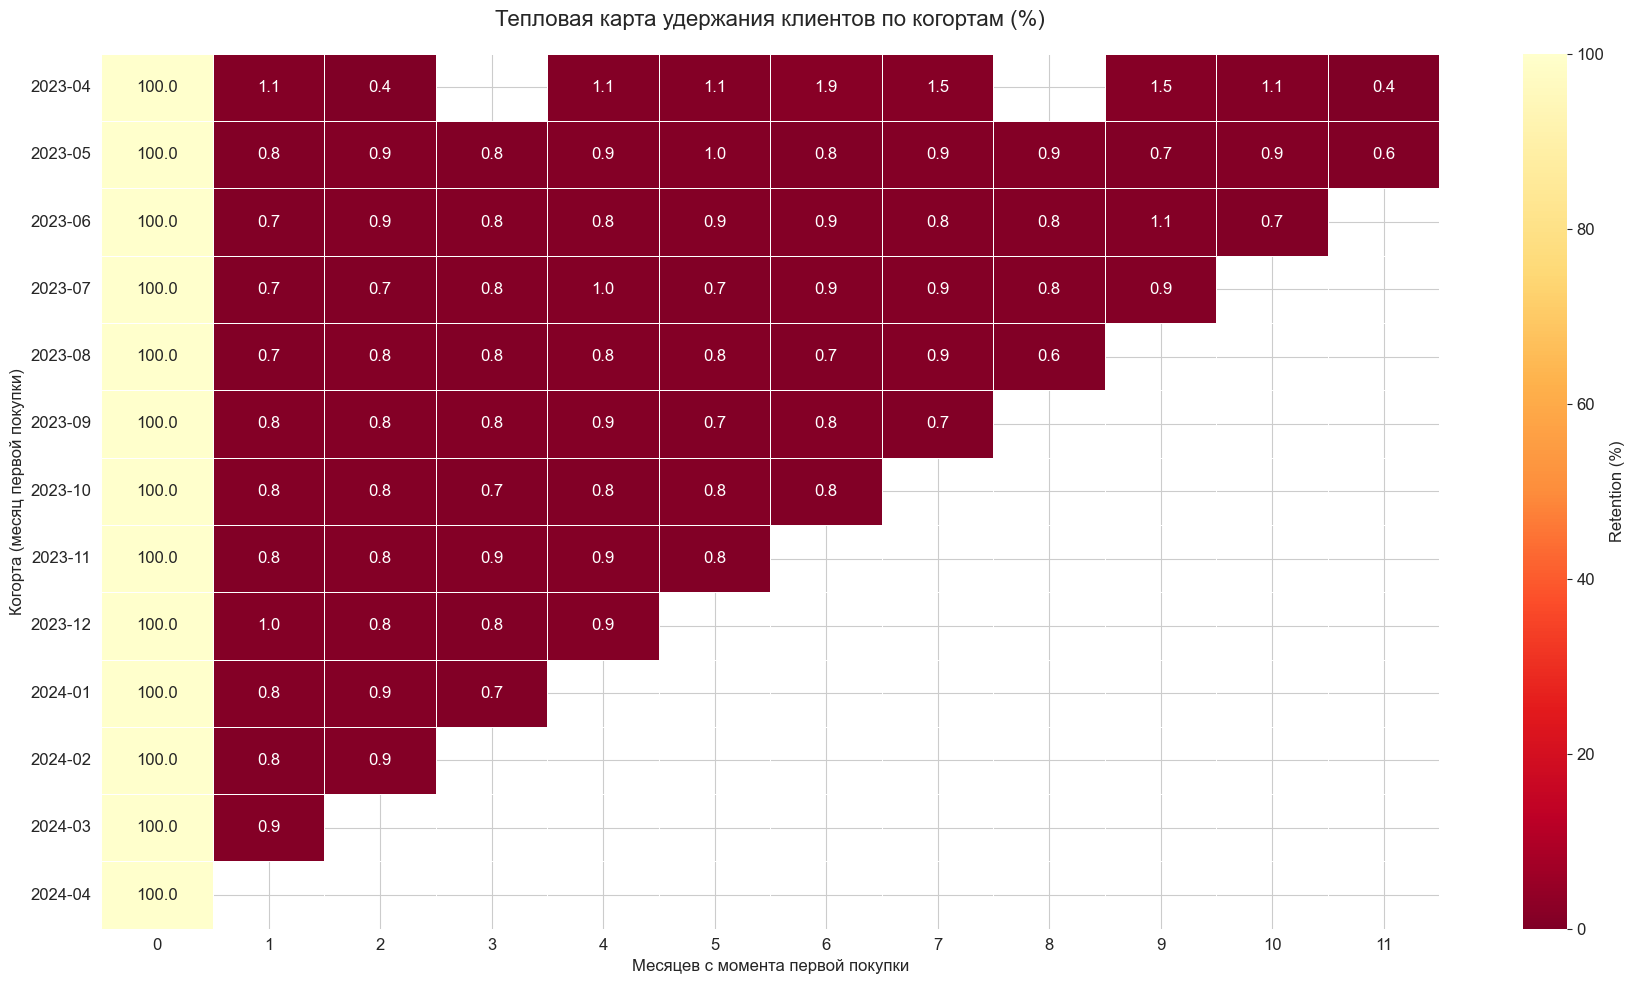

In [12]:
cohort_data = df.groupby(['Cohort', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='Cohort', columns='CohortIndex', values='CustomerID')
cohort_sizes_arr = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_sizes_arr, axis=0) * 100

plt.figure(figsize=(18, 10))
sns.heatmap(
    retention,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd_r',
    mask=retention.isnull(),
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    cbar_kws={'label': 'Retention (%)'},
    yticklabels=[str(c) for c in retention.index]
)
plt.title('Тепловая карта удержания клиентов по когортам (%)', fontsize=16, pad=20)
plt.xlabel('Месяцев с момента первой покупки')
plt.ylabel('Когорта (месяц первой покупки)')
plt.tight_layout()
plt.show()

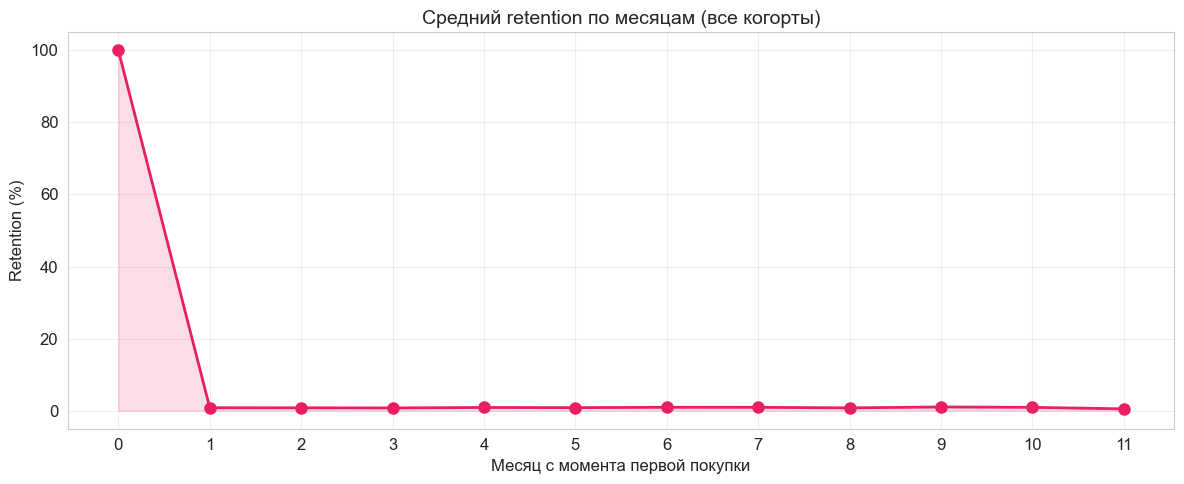

Retention на 1-й месяц: 0.8%
Retention на 3-й месяц: 0.8%
Retention на 6-й месяц: 1.0%


In [13]:
avg_retention = retention.mean()
plt.figure(figsize=(12, 5))
plt.plot(avg_retention.index, avg_retention.values, 'o-', color=COLORS[3], linewidth=2, markersize=8)
plt.fill_between(avg_retention.index, avg_retention.values, alpha=0.15, color=COLORS[3])
plt.title('Средний retention по месяцам (все когорты)', fontsize=14)
plt.xlabel('Месяц с момента первой покупки')
plt.ylabel('Retention (%)')
plt.xticks(avg_retention.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Retention на 1-й месяц: {avg_retention.get(1, 0):.1f}%')
print(f'Retention на 3-й месяц: {avg_retention.get(3, 0):.1f}%')
print(f'Retention на 6-й месяц: {avg_retention.get(6, 0):.1f}%')

## 6. Retention по временным окнам (7, 30, 90 дней)

Рассчитаем долю клиентов, вернувшихся за повторной покупкой в течение 7, 30 и 90 дней после первой покупки — по каждой когорте.

In [14]:
repeat_purchases = df[df['DaysSinceFirst'] > 0]
windows = {'7 дней': 7, '30 дней': 30, '90 дней': 90}

total_per_cohort = first_purchase.groupby('Cohort')['CustomerID'].nunique()

retention_windows = {}
for name, max_days in windows.items():
    retained = (
        repeat_purchases[repeat_purchases['DaysSinceFirst'] <= max_days]
        .groupby('Cohort')['CustomerID'].nunique()
    )
    retention_windows[name] = (retained / total_per_cohort * 100).fillna(0)

ret_win_df = pd.DataFrame(retention_windows)
ret_win_df.index = ret_win_df.index.astype(str)

print('Retention по временным окнам (%):')
ret_win_df.round(2)

Retention по временным окнам (%):


,7 дней,30 дней,90 дней
Cohort,,,
2023-04,0.00,1.14,1.52
2023-05,0.29,1.01,2.63
2023-06,0.15,0.77,2.38
2023-07,0.14,0.63,1.97
2023-08,0.19,0.82,2.12
2023-09,0.24,0.78,2.30
2023-10,0.21,0.72,2.30
2023-11,0.20,0.80,2.50
2023-12,0.21,0.74,2.50


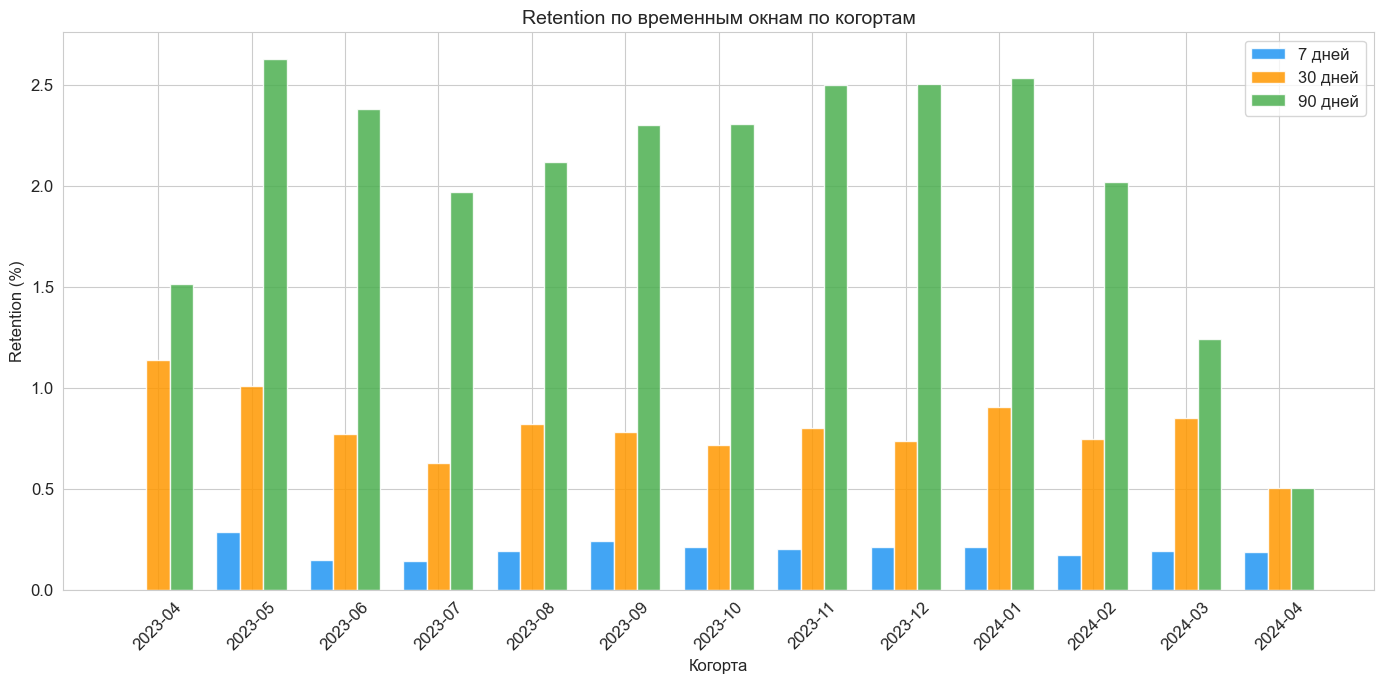


Общий retention (все когорты):
  7 дней: 0.20% (191 из 95,215)
  30 дней: 0.78% (741 из 95,215)
  90 дней: 2.10% (2,003 из 95,215)


In [15]:
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(ret_win_df))
width = 0.25

ax.bar(x - width, ret_win_df['7 дней'], width, label='7 дней', color=COLORS[0], alpha=0.85)
ax.bar(x, ret_win_df['30 дней'], width, label='30 дней', color=COLORS[1], alpha=0.85)
ax.bar(x + width, ret_win_df['90 дней'], width, label='90 дней', color=COLORS[2], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ret_win_df.index, rotation=45)
ax.set_title('Retention по временным окнам по когортам', fontsize=14)
ax.set_xlabel('Когорта')
ax.set_ylabel('Retention (%)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('\nОбщий retention (все когорты):')
total_customers = first_purchase['CustomerID'].nunique()
for name, max_days in windows.items():
    retained = repeat_purchases[repeat_purchases['DaysSinceFirst'] <= max_days]['CustomerID'].nunique()
    print(f'  {name}: {retained / total_customers * 100:.2f}% ({retained:,} из {total_customers:,})')

## 7. Сегментация по способу оплаты

В исходных данных нет канала привлечения, но способ оплаты может быть косвенным индикатором типа клиента. Сравним retention для разных способов оплаты.

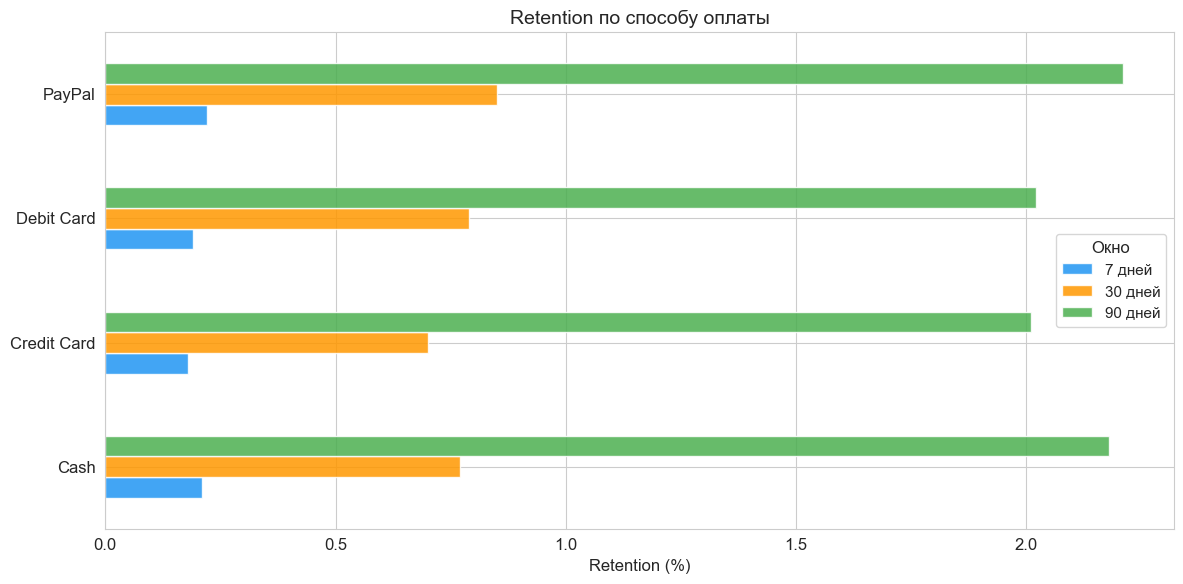


Детали по сегментам:


Окно,7 дней,30 дней,90 дней
Способ оплаты,,,
Cash,0.21,0.77,2.18
Credit Card,0.18,0.70,2.01
Debit Card,0.19,0.79,2.02
PayPal,0.22,0.85,2.21


In [16]:
first_tx = df.sort_values('TransactionDate').groupby('CustomerID').first().reset_index()
cust_payment = first_tx[['CustomerID', 'PaymentMethod']].rename(columns={'PaymentMethod': 'FirstPayment'})

first_purchase_seg = first_purchase.merge(cust_payment, on='CustomerID')
repeat_seg = repeat_purchases.merge(cust_payment, on='CustomerID')

seg_results = []
for method in sorted(df['PaymentMethod'].unique()):
    total = first_purchase_seg[first_purchase_seg['FirstPayment'] == method]['CustomerID'].nunique()
    for name, max_days in windows.items():
        retained = repeat_seg[
            (repeat_seg['FirstPayment'] == method) &
            (repeat_seg['DaysSinceFirst'] <= max_days)
        ]['CustomerID'].nunique()
        seg_results.append({
            'Способ оплаты': method,
            'Окно': name,
            'Retention (%)': round(retained / total * 100, 2) if total > 0 else 0,
            'Клиентов': total
        })

seg_df = pd.DataFrame(seg_results)
seg_pivot = seg_df.pivot_table(index='Способ оплаты', columns='Окно', values='Retention (%)')
seg_pivot = seg_pivot[['7 дней', '30 дней', '90 дней']]

fig, ax = plt.subplots(figsize=(12, 6))
seg_pivot.plot(kind='barh', ax=ax, color=COLORS[:3], alpha=0.85)
ax.set_title('Retention по способу оплаты', fontsize=14)
ax.set_xlabel('Retention (%)')
ax.set_ylabel('')
ax.legend(title='Окно', fontsize=11)
plt.tight_layout()
plt.show()

print('\nДетали по сегментам:')
seg_pivot

## 8. Сегментация по категории товаров

Определим основную категорию каждого клиента (по первой покупке) и сравним retention между категориями.

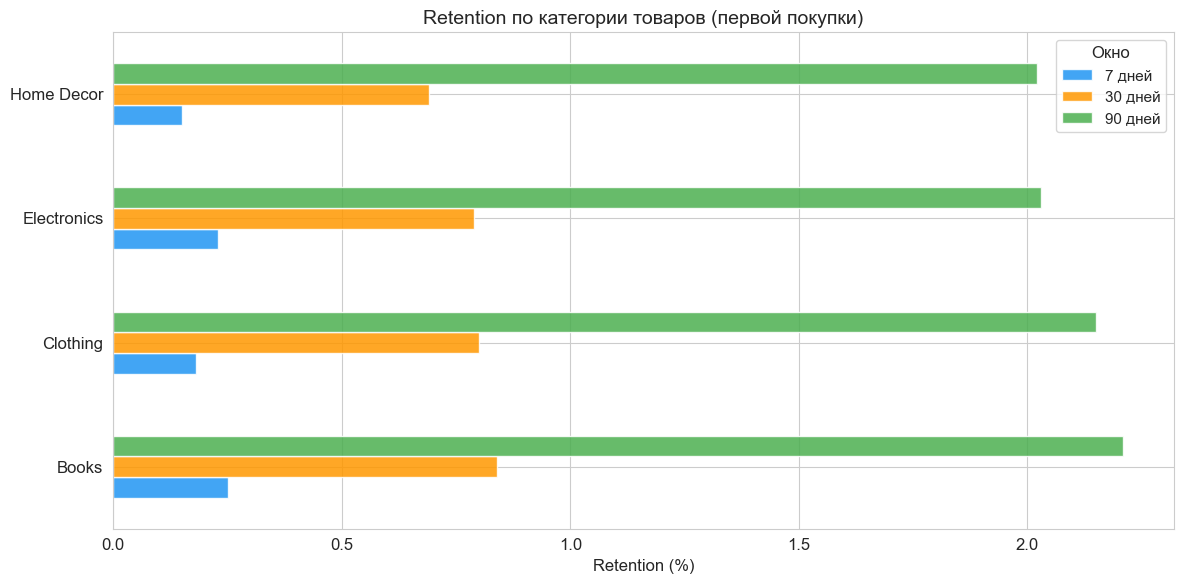

Окно,7 дней,30 дней,90 дней
Категория,,,
Books,0.25,0.84,2.21
Clothing,0.18,0.80,2.15
Electronics,0.23,0.79,2.03
Home Decor,0.15,0.69,2.02


In [17]:
cust_category = first_tx[['CustomerID', 'ProductCategory']].rename(columns={'ProductCategory': 'FirstCategory'})

first_purchase_cat = first_purchase.merge(cust_category, on='CustomerID')
repeat_cat = repeat_purchases.merge(cust_category, on='CustomerID')

cat_results = []
for cat in sorted(df['ProductCategory'].unique()):
    total = first_purchase_cat[first_purchase_cat['FirstCategory'] == cat]['CustomerID'].nunique()
    for name, max_days in windows.items():
        retained = repeat_cat[
            (repeat_cat['FirstCategory'] == cat) &
            (repeat_cat['DaysSinceFirst'] <= max_days)
        ]['CustomerID'].nunique()
        cat_results.append({
            'Категория': cat,
            'Окно': name,
            'Retention (%)': round(retained / total * 100, 2) if total > 0 else 0,
            'Клиентов': total
        })

cat_df = pd.DataFrame(cat_results)
cat_pivot = cat_df.pivot_table(index='Категория', columns='Окно', values='Retention (%)')
cat_pivot = cat_pivot[['7 дней', '30 дней', '90 дней']]

fig, ax = plt.subplots(figsize=(12, 6))
cat_pivot.plot(kind='barh', ax=ax, color=COLORS[:3], alpha=0.85)
ax.set_title('Retention по категории товаров (первой покупки)', fontsize=14)
ax.set_xlabel('Retention (%)')
ax.set_ylabel('')
ax.legend(title='Окно', fontsize=11)
plt.tight_layout()
plt.show()

cat_pivot

## 9. Перекрёстная сегментация: категория × способ оплаты

Углубляемся: смотрим 90-дневный retention в разрезе обоих сегментов одновременно.

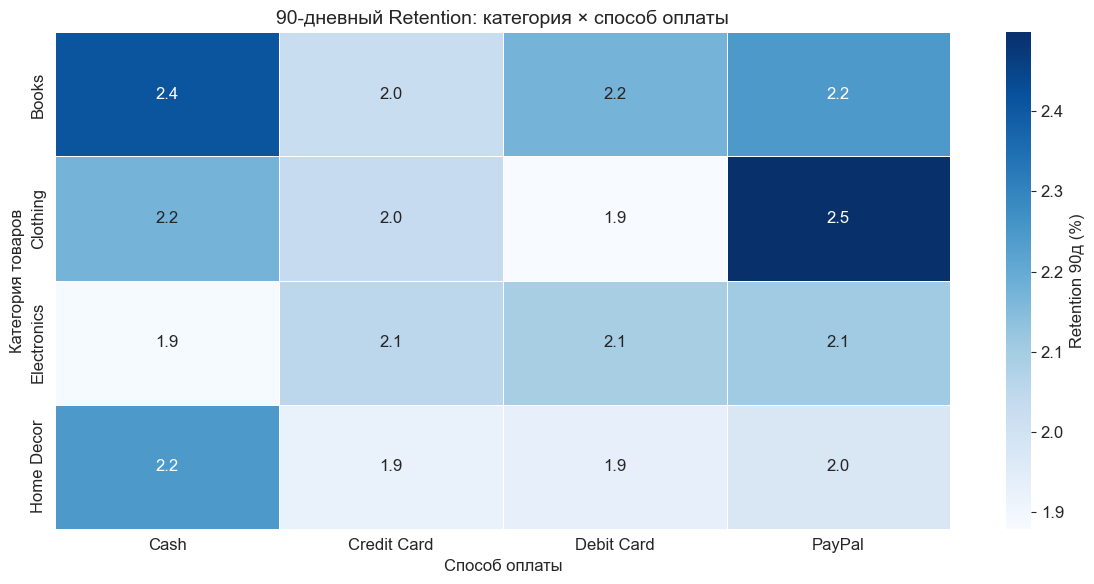

In [18]:
cust_both = first_tx[['CustomerID', 'PaymentMethod', 'ProductCategory']]
repeat_both = repeat_purchases[repeat_purchases['DaysSinceFirst'] <= 90].merge(
    cust_both, on='CustomerID', suffixes=('', '_first')
)
first_both = first_purchase.merge(cust_both, on='CustomerID')

total_cross = first_both.groupby(['ProductCategory', 'PaymentMethod'])['CustomerID'].nunique()
retained_cross = repeat_both.groupby(['ProductCategory_first', 'PaymentMethod_first'])['CustomerID'].nunique()
retained_cross.index.names = ['ProductCategory', 'PaymentMethod']

cross_retention = (retained_cross / total_cross * 100).fillna(0).unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(cross_retention, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Retention 90д (%)'})
plt.title('90-дневный Retention: категория × способ оплаты', fontsize=14)
plt.xlabel('Способ оплаты')
plt.ylabel('Категория товаров')
plt.tight_layout()
plt.show()

## 10. RFM-анализ

Сегментируем клиентов по трём измерениям:
- **Recency** — сколько дней прошло с последней покупки
- **Frequency** — сколько покупок совершил клиент
- **Monetary** — сколько денег потратил клиент

In [19]:
snapshot_date = df['TransactionDate'].max() + timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('TransactionDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('TransactionDate', 'count'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

def rfm_segment(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

print('Распределение по RFM-сегментам:')
seg_dist = rfm['Segment'].value_counts()
for seg, cnt in seg_dist.items():
    print(f'  {seg}: {cnt:,} клиентов ({cnt / len(rfm) * 100:.1f}%)')

Распределение по RFM-сегментам:
  At Risk: 22,207 клиентов (23.3%)
  Loyal: 18,919 клиентов (19.9%)
  Champions: 16,003 клиентов (16.8%)
  Lost: 15,771 клиентов (16.6%)
  New Customers: 14,808 клиентов (15.6%)
  Regular: 7,507 клиентов (7.9%)


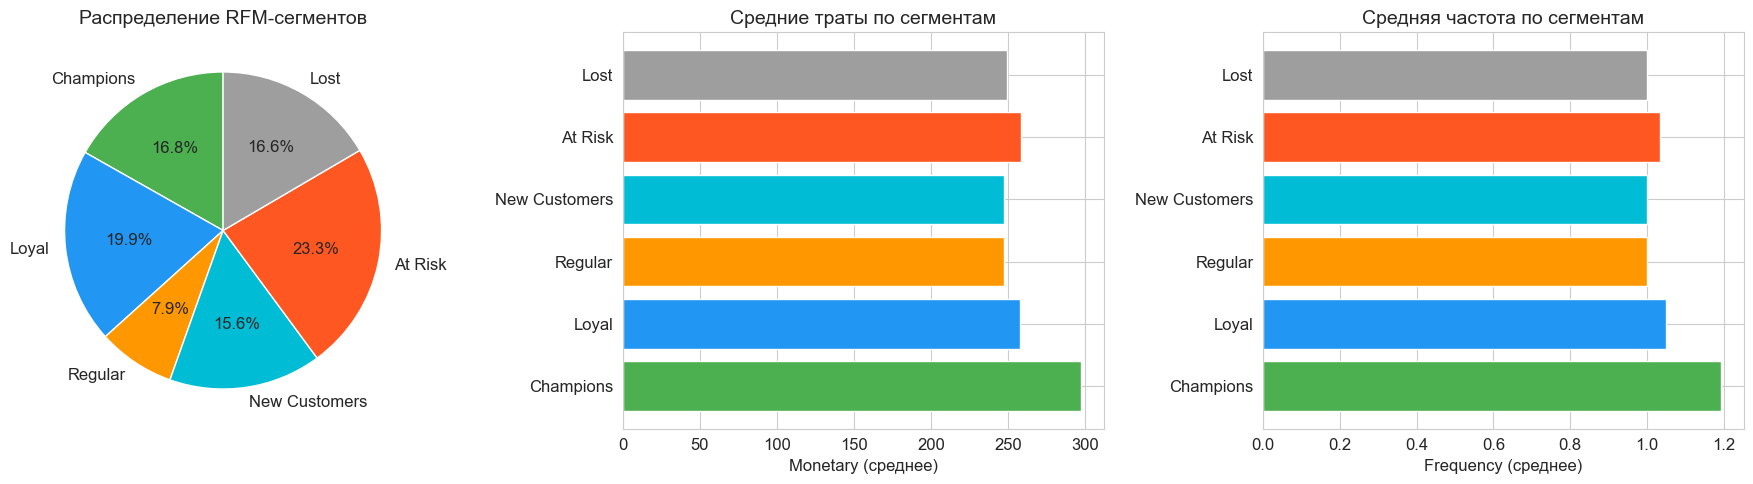

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

seg_order = ['Champions', 'Loyal', 'Regular', 'New Customers', 'At Risk', 'Lost']
seg_colors = ['#4CAF50', '#2196F3', '#FF9800', '#00BCD4', '#FF5722', '#9E9E9E']

# Pie chart
seg_counts = rfm['Segment'].value_counts().reindex(seg_order).dropna()
axes[0].pie(seg_counts.values, labels=seg_counts.index, colors=seg_colors[:len(seg_counts)],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Распределение RFM-сегментов')

# Avg monetary by segment
seg_monetary = rfm.groupby('Segment')['Monetary'].mean().reindex(seg_order).dropna()
axes[1].barh(seg_monetary.index, seg_monetary.values, color=seg_colors[:len(seg_monetary)])
axes[1].set_title('Средние траты по сегментам')
axes[1].set_xlabel('Monetary (среднее)')

# Avg frequency by segment
seg_freq = rfm.groupby('Segment')['Frequency'].mean().reindex(seg_order).dropna()
axes[2].barh(seg_freq.index, seg_freq.values, color=seg_colors[:len(seg_freq)])
axes[2].set_title('Средняя частота по сегментам')
axes[2].set_xlabel('Frequency (среднее)')

plt.tight_layout()
plt.show()

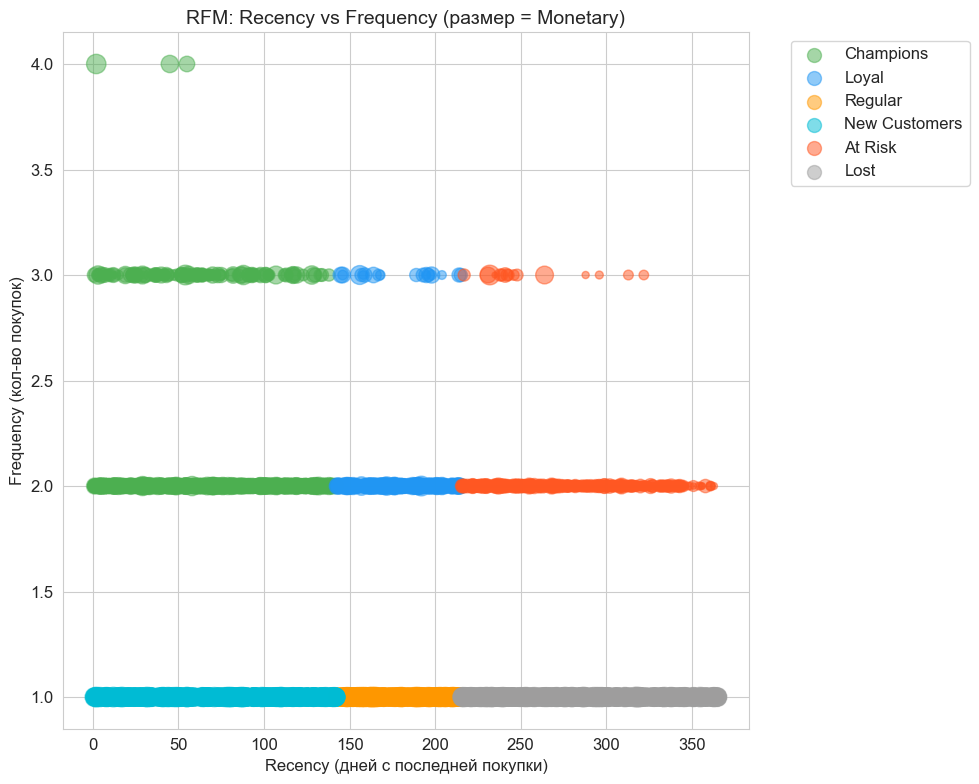

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
for i, seg in enumerate(seg_order):
    subset = rfm[rfm['Segment'] == seg]
    if len(subset) > 0:
        ax.scatter(subset['Recency'], subset['Frequency'],
                   s=subset['Monetary'] / subset['Monetary'].max() * 200,
                   alpha=0.5, label=seg, color=seg_colors[i])

ax.set_title('RFM: Recency vs Frequency (размер = Monetary)', fontsize=14)
ax.set_xlabel('Recency (дней с последней покупки)')
ax.set_ylabel('Frequency (кол-во покупок)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 11. Средний чек, LTV и динамика выручки по когортам

Рассмотрим, как средний чек и кумулятивная выручка меняются в зависимости от когорты и времени.

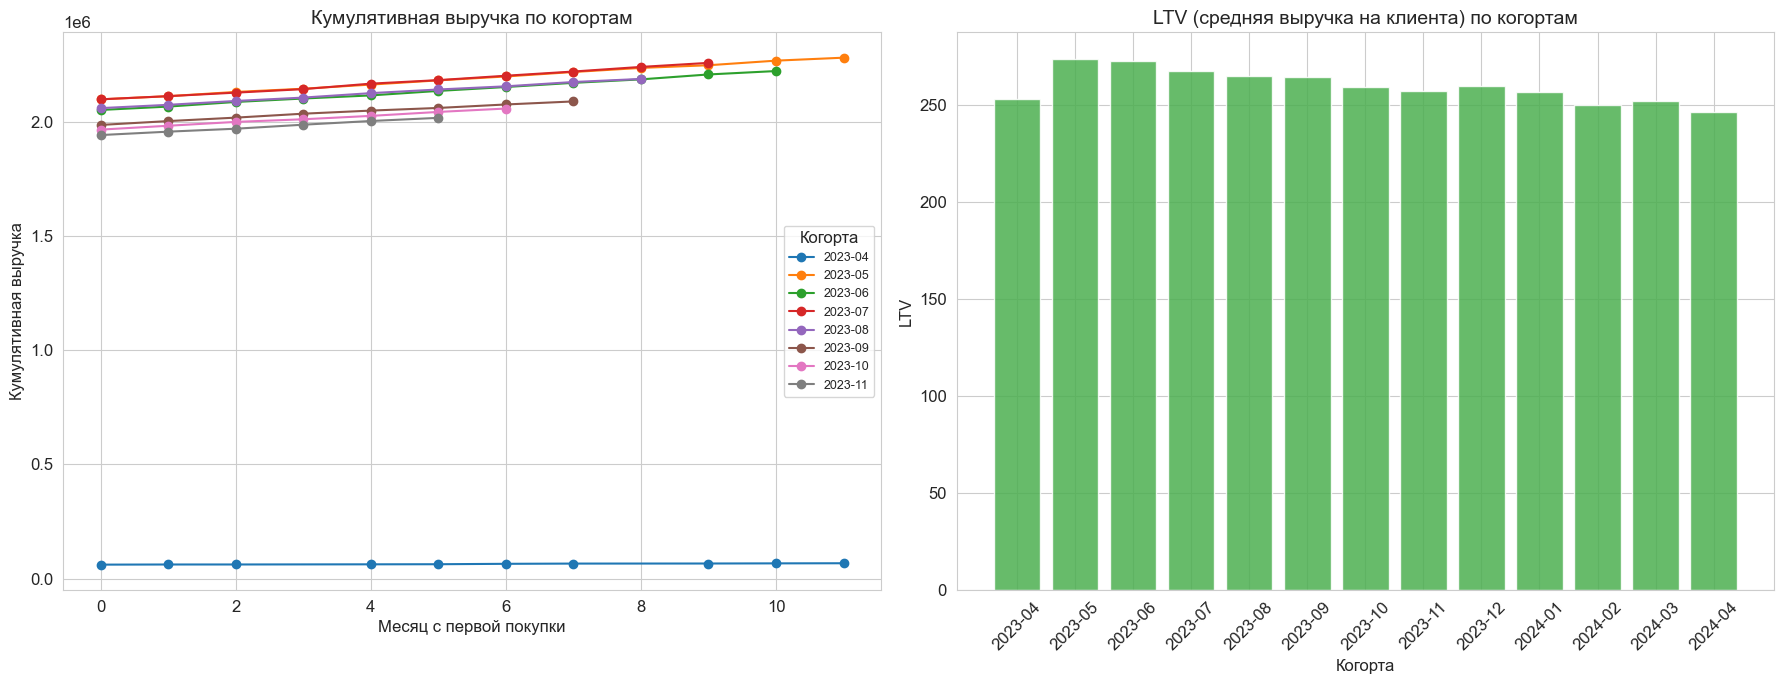

In [22]:
cohort_revenue = df.groupby(['Cohort', 'CohortIndex']).agg(
    revenue=('TotalAmount', 'sum'),
    avg_check=('TotalAmount', 'mean'),
    transactions=('CustomerID', 'count')
).reset_index()

# Cumulative revenue per cohort
cohort_cum_rev = cohort_revenue.pivot_table(index='Cohort', columns='CohortIndex', values='revenue')
cohort_cum_rev = cohort_cum_rev.cumsum(axis=1)

# Average check pivot
cohort_avg_check = cohort_revenue.pivot_table(index='Cohort', columns='CohortIndex', values='avg_check')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, cohort in enumerate(cohort_cum_rev.index[:8]):
    data = cohort_cum_rev.loc[cohort].dropna()
    axes[0].plot(data.index, data.values, 'o-', label=str(cohort), linewidth=1.5)

axes[0].set_title('Кумулятивная выручка по когортам', fontsize=14)
axes[0].set_xlabel('Месяц с первой покупки')
axes[0].set_ylabel('Кумулятивная выручка')
axes[0].legend(title='Когорта', fontsize=9)

# LTV per customer by cohort
ltv = df.groupby('Cohort')['TotalAmount'].sum() / cohort_sizes
ltv_plot = ltv.reset_index()
ltv_plot.columns = ['Cohort', 'LTV']
ltv_plot['Cohort'] = ltv_plot['Cohort'].astype(str)

axes[1].bar(ltv_plot['Cohort'], ltv_plot['LTV'], color=COLORS[2], alpha=0.85)
axes[1].set_title('LTV (средняя выручка на клиента) по когортам', fontsize=14)
axes[1].set_xlabel('Когорта')
axes[1].set_ylabel('LTV')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

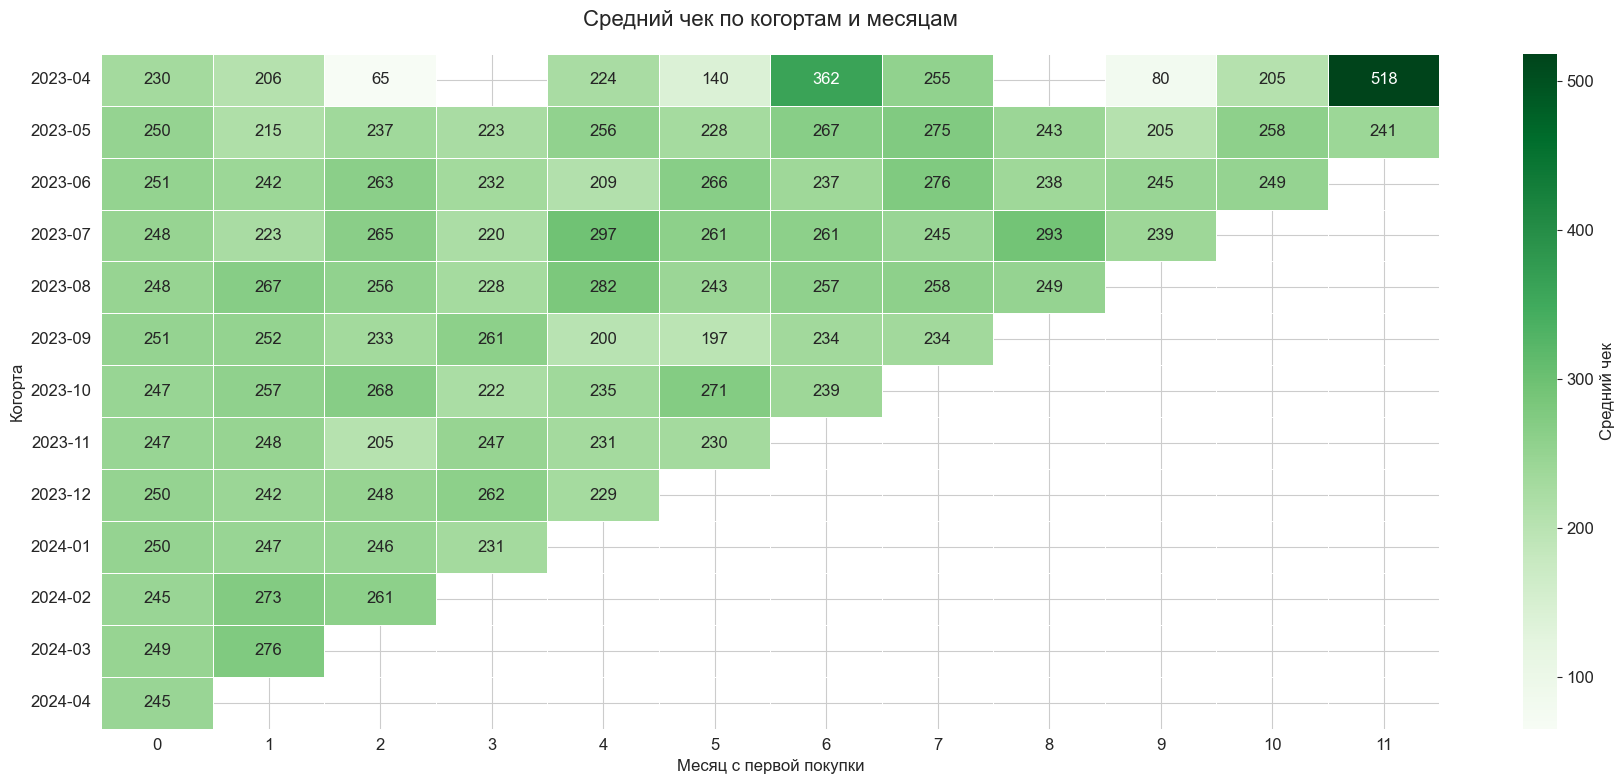

In [23]:
plt.figure(figsize=(18, 8))
sns.heatmap(
    cohort_avg_check,
    annot=True,
    fmt='.0f',
    cmap='Greens',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Средний чек'},
    yticklabels=[str(c) for c in cohort_avg_check.index]
)
plt.title('Средний чек по когортам и месяцам', fontsize=16, pad=20)
plt.xlabel('Месяц с первой покупки')
plt.ylabel('Когорта')
plt.tight_layout()
plt.show()

## 12. Географический анализ

Извлечём штат из адреса магазина и посмотрим региональные различия.

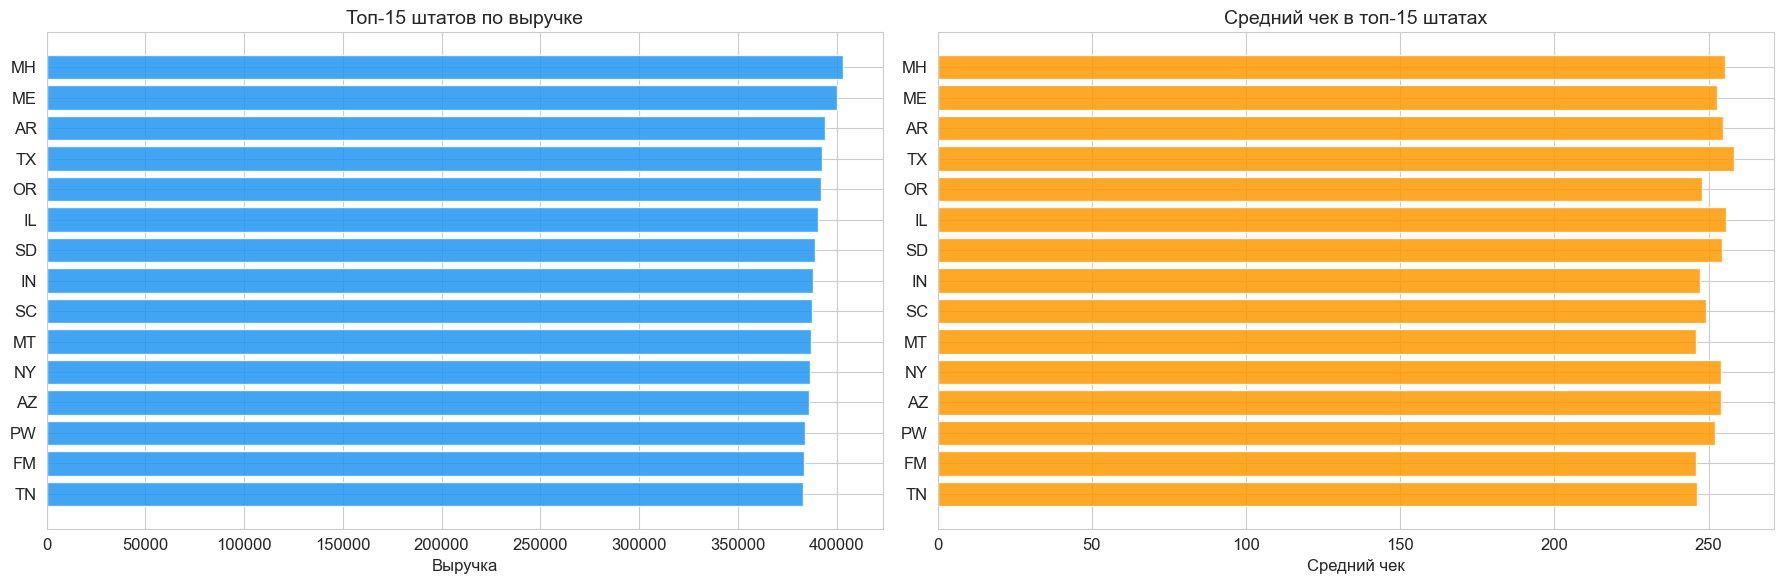

Всего штатов: 59

Топ-5 по выручке:


,revenue,customers,avg_check
State,,,
MH,403259.0,1576,255.0
ME,400061.0,1583,253.0
AR,393846.0,1546,255.0
TX,392308.0,1518,258.0
OR,392179.0,1577,248.0


In [24]:
state_stats = df.groupby('State').agg(
    revenue=('TotalAmount', 'sum'),
    transactions=('CustomerID', 'count'),
    customers=('CustomerID', 'nunique'),
    avg_check=('TotalAmount', 'mean')
).sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_states = state_stats.head(15)
axes[0].barh(top_states.index[::-1], top_states['revenue'][::-1], color=COLORS[0], alpha=0.85)
axes[0].set_title('Топ-15 штатов по выручке', fontsize=14)
axes[0].set_xlabel('Выручка')

axes[1].barh(top_states.index[::-1], top_states['avg_check'][::-1], color=COLORS[1], alpha=0.85)
axes[1].set_title('Средний чек в топ-15 штатах', fontsize=14)
axes[1].set_xlabel('Средний чек')

plt.tight_layout()
plt.show()

print(f'Всего штатов: {state_stats.index.nunique()}')
print(f'\nТоп-5 по выручке:')
state_stats[['revenue', 'customers', 'avg_check']].head().round(0)

## 13. Влияние скидок на поведение клиентов

Проверим, влияет ли размер скидки на вероятность повторной покупки.

Скидка для возвращающихся vs одноразовых клиентов:
              mean  median   std
Одноразовые  10.01   10.02  5.78
Вернувшиеся  10.11   10.15  5.77


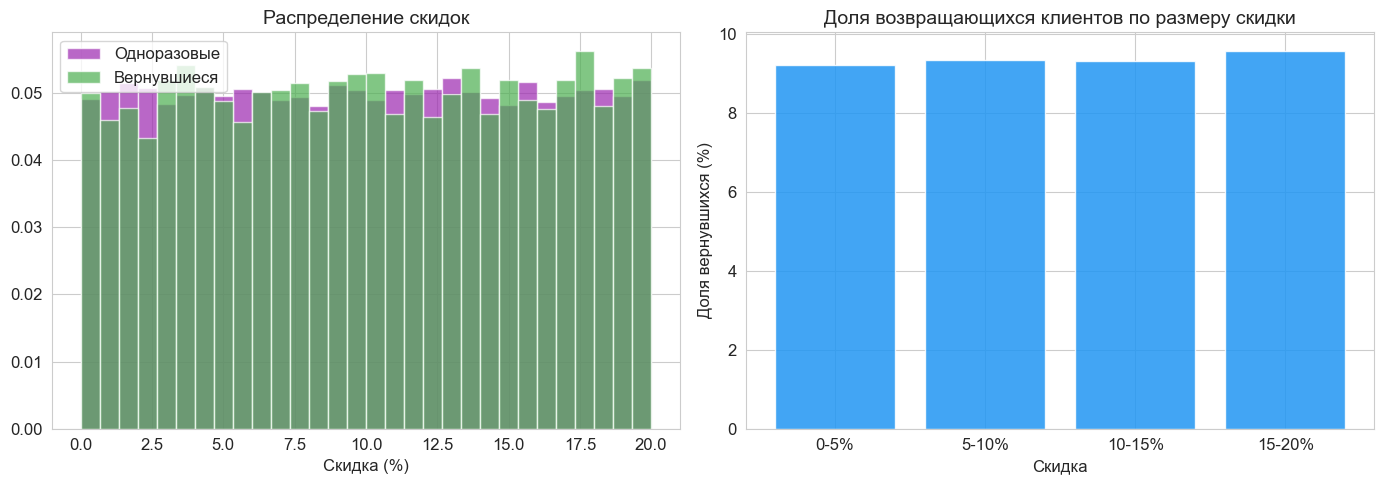

In [25]:
# Average discount for returning vs one-time customers
returning_customers = repeat_purchases['CustomerID'].unique()

df['IsReturning'] = df['CustomerID'].isin(returning_customers)

disc_analysis = df.groupby('IsReturning')['DiscountApplied(%)'].agg(['mean', 'median', 'std'])
disc_analysis.index = ['Одноразовые', 'Вернувшиеся']
print('Скидка для возвращающихся vs одноразовых клиентов:')
print(disc_analysis.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['IsReturning'] == False]['DiscountApplied(%)'].hist(
    bins=30, ax=axes[0], color=COLORS[4], alpha=0.7, label='Одноразовые', density=True)
df[df['IsReturning'] == True]['DiscountApplied(%)'].hist(
    bins=30, ax=axes[0], color=COLORS[2], alpha=0.7, label='Вернувшиеся', density=True)
axes[0].set_title('Распределение скидок')
axes[0].set_xlabel('Скидка (%)')
axes[0].legend()

# Discount bins vs retention
df['DiscountBin'] = pd.cut(df['DiscountApplied(%)'], bins=[0, 5, 10, 15, 20, 25], labels=['0-5%', '5-10%', '10-15%', '15-20%', '20-25%'])
disc_ret = df.groupby('DiscountBin')['IsReturning'].mean() * 100
axes[1].bar(disc_ret.index.astype(str), disc_ret.values, color=COLORS[0], alpha=0.85)
axes[1].set_title('Доля возвращающихся клиентов по размеру скидки')
axes[1].set_xlabel('Скидка')
axes[1].set_ylabel('Доля вернувшихся (%)')

plt.tight_layout()
plt.show()

## 14. Выводы и гипотезы

### Факты из данных

**Общая статистика:**
- Датасет содержит **100 000 транзакций** за период **2023-04-29 — 2024-04-28** ( 1 год).
- Число уникальных клиентов — **95 215** из 100 000 транзакций, то есть подавляющее большинство (~95%) совершает лишь одну покупку.
- 4 категории товаров и 4 способа оплаты представлены в данных приблизительно в одинаковых пропорциях.

**Когортный анализ и Retention:**
- Размеры когорт практически одинаковы — от ~7 500 до ~8 400 новых клиентов в месяц (за исключением неполных первого и последнего месяцев).
- Retention крайне низкий на всех горизонтах: **0.8%** на 1-й месяц, **0.8%** на 3-й, **1.0%** на 6-й.
- Retention по окнам: **0.20%** за 7 дней (191 из 95 215), **0.78%** за 30 дней (741), **2.10%** за 90 дней (2 003).
- Все когорты ведут себя практически идентично — разброс retention минимален. **Сезонных эффектов не обнаружено**: декабрьская когорта (2023-12) показывает retention 0.21% / 0.74% / 2.50%, что не отличается значимо от других когорт.
- Кривая среднего retention плоская: нет характерного для реальных данных резкого падения в первые месяцы с последующей стабилизацией.

**Сегментация:**
- Способ оплаты и категория товаров не оказывают значимого влияния на retention — показатели удержания по всем сегментам очень близки.
- Перекрёстная сегментация (категория × способ оплаты) также не выявляет значимых различий.

**Влияние скидок:**
- Средний размер скидки у одноразовых клиентов (**10.01%**) и вернувшихся (**10.11%**) практически идентичен.
- Размер скидки не коррелирует с вероятностью возврата — распределения скидок по группам совпадают.

**RFM-анализ:**
- Сегменты распределены относительно равномерно: At Risk (23.3%), Loyal (19.9%), Champions (16.8%), Lost (16.6%), New Customers (15.6%), Regular (7.9%).
- В реальных данных обычно наблюдается явное «тяжёлое хвосто» — малая группа Champions генерирует непропорционально большую выручку. Здесь такого эффекта нет.

### Ключевой вывод

Полученные результаты — однородность когорт, отсутствие сезонных эффектов, нулевая корреляция скидок с retention, равномерное распределение RFM-сегментов — указывают на то, что датасет является синтетическим. 

### Гипотезы: что бы можно было бы найти  в реальных данных

1. **Сезонность**: в реальном ритейле декабрьские когорты обычно имеют retention ниже среднего из-за разовых подарочных покупок. В нашем датасете это не подтвердилось (когорты однородны).
2. **Влияние способа оплаты**: в реальности клиенты с привязанной картой (Credit/Debit) обычно более лояльны, чем пользователи Cash. В наших данных различий не обнаружено.
3. **Влияние скидок**: на практике агрессивные скидки (>15%) могут привлекать «черри-пикеров» с низким retention. Наш анализ показал, что скидки распределены одинаково между группами и не влияют на возвращаемость.
4. **Кросс-категорийный переход**: в реальных данных клиенты, покупающие из 2+ категорий, обычно показывают более высокий retention. Это направление можно было бы исследовать при наличии реальных данных.
5. **Географические различия**: в реальности retention может существенно различаться по регионам. Наш датасет содержит 59 штатов с примерно одинаковыми показателями.
